# Task 2: Poisson regression
### Clara Hardes, 07.09.2026

In this file Poisson regression is applied to investigate the relation between time and number of birds. For this the following variables of the bird_count.csv are used:
- yr (Year of bird counts)
- count (number of counted birds) 

For that in this we try to maximize the log likelihood function for Poisson GLM:

$$
\begin{aligned}
\log l(y \mid \beta_0,\beta_1,\ldots,\beta_p,x)
&=
\sum_{i=1}^{n}
\left[
-\lambda(x_i)
+y_i\log(\lambda(x_i))
-\log(y_i!)
\right] \\
&=
\sum_{i=1}^{n}
\left[
-e^{\beta_0+\beta_1x_{i1}+\cdots+\beta_px_{ip}}
+y_i(\beta_0+\beta_1x_{i1}+\cdots+\beta_px_{ip})
-\log(y_i!)
\right].
\end{aligned}
$$

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.special import factorial
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"bird_count.csv")

In [3]:
#adjust years (new_year = old_year - min(year), so that the exponential is not exploding
df['yr_num'] = [yr - min(df['yr']) for yr in df['yr']]

In [4]:
#select adjusted year values for x and bird counts for y
x = df['yr_num']
y = df['count']


def objective(param,x,y): #x=year,y=count
    '''
    objective function: implements the log likelyhood function for Poisson GLM and returns the neg(log_likelihood) 
    --> so that scipy.optimize.minimize can be used (although we want to maximize the function)
    '''
    b0,b1 = param #the parameters to optimize
    log_lam = b0 + b1*x
    lam = np.exp(log_lam)
    return -(np.sum(-(lam) + y*(log_lam) - np.log(factorial(y))))


result = minimize(
    objective,
    x0=[0, 0],
    args=(x, y)
)

beta_hat = result.x
print(beta_hat)
print(result)


[ 2.32533196 -0.03244318]
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 34.68262701273443
        x: [ 2.325e+00 -3.244e-02]
      nit: 9
      jac: [ 1.431e-06  0.000e+00]
 hess_inv: [[ 2.988e-02 -3.350e-03]
            [-3.350e-03  5.447e-04]]
     nfev: 42
     njev: 14


In [5]:
# calculte the estimated count with the optimized parameters
df['est_count'] = np.exp(beta_hat[0] + beta_hat[1]*x)

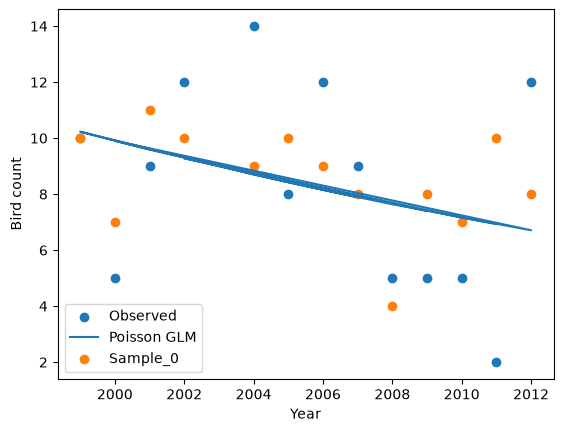

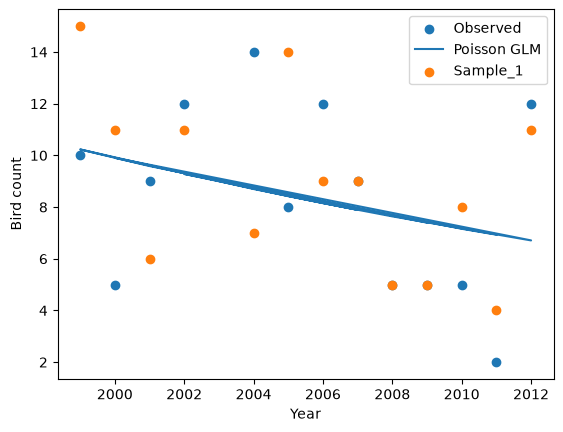

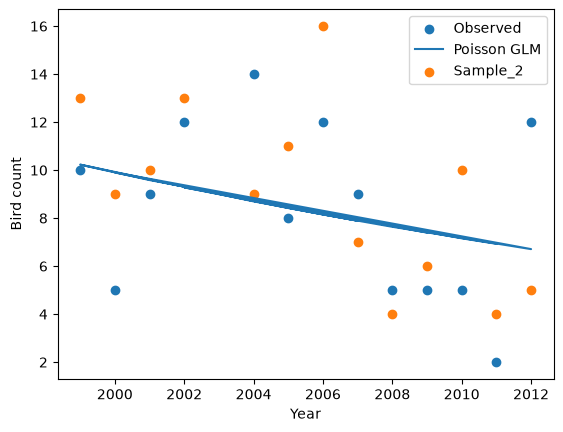

In [6]:
# sampling from the estimated counts + plotting
samples = pd.DataFrame()
samples['yr'] = df['yr']
for i in range(3):
    samples[f'sample_{i}'] = np.random.poisson(df['est_count'])
    plt.scatter(df['yr'], df['count'], label='Observed')
    plt.plot(df['yr'], df['est_count'], label='Poisson GLM')
    plt.scatter(df['yr'],samples[f'sample_{i}'],label=f"Sample_{i}")
    plt.xlabel('Year')
    plt.ylabel('Bird count')
    plt.legend()
    plt.show()

In [78]:
samples

,yr,sample_0,sample_1,sample_2
0,2011,9,4,10
1,2010,11,5,8
2,2002,10,12,10
3,2006,4,10,12
4,2008,3,8,11
5,2012,5,8,6
6,2000,10,7,13
7,2005,8,12,8
8,2007,7,5,6
9,2004,5,12,8


In [80]:
#save samples as csv
samples.to_csv("samples.csv",index=False)

# Little experiment with also including observerAge in the model

In [81]:

x1 = df['yr_num']
x2 = df['observerAge']
y = df['count']

def objective(param,x1,x2,y): #x=year,y=count
    b0,b1,b2 = param
    log_lam = b0 + b1*x + b2*x2
    lam = np.exp(log_lam)
    return -(np.sum(-(lam) + y*(log_lam) - np.log(factorial(y))))


result = minimize(
    objective,
    x0=[0, 0, 0],
    args=(x1, x2, y)
)

beta_hat = result.x
print(beta_hat)
print(result)


[ 1.89638162 -0.08494058  0.01506885]
      fun: 34.09664229287109
 hess_inv: array([[ 1.46509007e-03, -1.64675153e-03,  1.81691269e-04],
       [-1.64675153e-03,  1.85548748e-03, -2.08734725e-04],
       [ 1.81691269e-04, -2.08734725e-04,  2.70427356e-05]])
      jac: array([-4.76837158e-07,  1.90734863e-05,  7.86781311e-05])
  message: 'Desired error not necessarily achieved due to precision loss.'
     nfev: 108
      nit: 11
     njev: 27
   status: 2
  success: False
        x: array([ 1.89638162, -0.08494058,  0.01506885])


In [82]:
est_count_2 = np.exp(beta_hat[0] + beta_hat[1]*x1 + beta_hat[2]*x2)

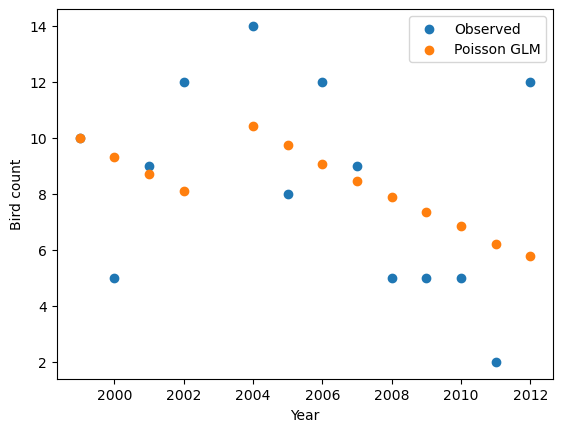

In [83]:
plt.scatter(df['yr'], df['count'], label='Observed')
plt.scatter(df['yr'], est_count_2, label='Poisson GLM')
plt.xlabel('Year')
plt.ylabel('Bird count')
plt.legend()
plt.show()